# Task 5: Polynomial regression with hyperparameter tuning

In [ ]:
# Read the data
import pandas as pa
import numpy as np
data = open("inc_utf.csv").readlines()
# Prepare the data with a list and comprehension
cleaned_data = [ (int(region[:2]),int(age.replace(" years","").replace("+","")), float(income))
                for row in data[1:]
                 for _, region, age, income in [row.strip().split(",")]]
# Calculate mean income per age
df = pa.DataFrame(cleaned_data, columns=["region", "age", "income"])
data_to_model = df.groupby("age")["income"].mean().to_frame().reset_index().sort_values(by=["age"], ascending=True).to_numpy()
# Specify a random generators seed, so shuffling generate the same shuffled indices
rng = np.random.default_rng(42)
rng.shuffle(data_to_model)
# split the data
train_set_size = int(len(data_to_model) * 0.8)
train_set, test_set = data_to_model[:train_set_size], data_to_model[train_set_size:]



In [61]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
# split the columns
age_train = train_set[:,0]
income_train = train_set[:,1]
list_of_degrees = [2, 3, 5, 8]

def create_model(nr_of_degrees: int) -> tuple[LinearRegression, PolynomialFeatures]:
    # Step 1, create the polynomial features for training the model
    features = PolynomialFeatures(degree=nr_of_degrees, include_bias=False)
    age_train_2d = age_train.reshape(-1, 1)
    X_poly_training = features.fit_transform(age_train_2d)
    # Step 2. Train the linear regression model on the poly features
    linear_reg = LinearRegression()
    linear_reg.fit(X_poly_training, income_train)

    # Step 3. Calculate MSE and RMSE
    age_test_2d = test_set[:,0].reshape(-1, 1)
    X_poly_testing = features.fit_transform(age_test_2d)
    y_prediction_test = linear_reg.predict(X_poly_testing)
    mse = np.mean((test_set[:,1] - y_prediction_test)**2)
    print(f"Using degree {degree}: MSE = {mse}, RMSE = {np.sqrt(mse)}")
    return linear_reg, features

for degree in list_of_degrees:
    create_model(degree)
# The 3rd degree polynomial regression is the best, it has the lowest RMSE which means the line deviates the least from the data points


Using degree 2: MSE = 1797.4689984646009, RMSE = 42.39656823924079
Using degree 3: MSE = 152.1364709154937, RMSE = 12.334361390663632
Using degree 5: MSE = 1352.360926988369, RMSE = 36.77446025420861
Using degree 8: MSE = 3491.8880152033184, RMSE = 59.09219927539775


Using degree 8: MSE = 152.1364709154937, RMSE = 12.334361390663632


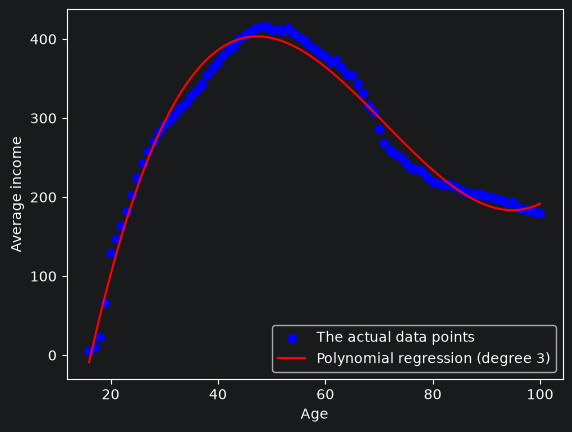

In [62]:
lin_reg, poly_features = create_model(3)
age_data = data_to_model[:,0]
income_data = data_to_model[:,1]

X_poly = poly_features.fit_transform(data_to_model[:,0].reshape(-1, 1))
income_pred = lin_reg.predict(X_poly)

sort_idx = np.argsort(age_data)
plt.scatter(age_data[sort_idx], income_data[sort_idx], color="blue", label="The actual data points")
plt.plot(age_data[sort_idx], income_pred[sort_idx], color="red", label="Polynomial regression (degree 3)")
plt.xlabel("Age")
plt.ylabel("Average income")
plt.legend()
plt.show()